In [1]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

jit_find_library(): Unable to load "/usr/lib/llvm-15/lib/libLLVM.so": /home/jonathan/miniconda3/envs/volprim/lib/python3.11/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/llvm-15/lib/libLLVM.so)!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.056627527..1.0546795].
/tmp/ipykernel_3598525/3890815811.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


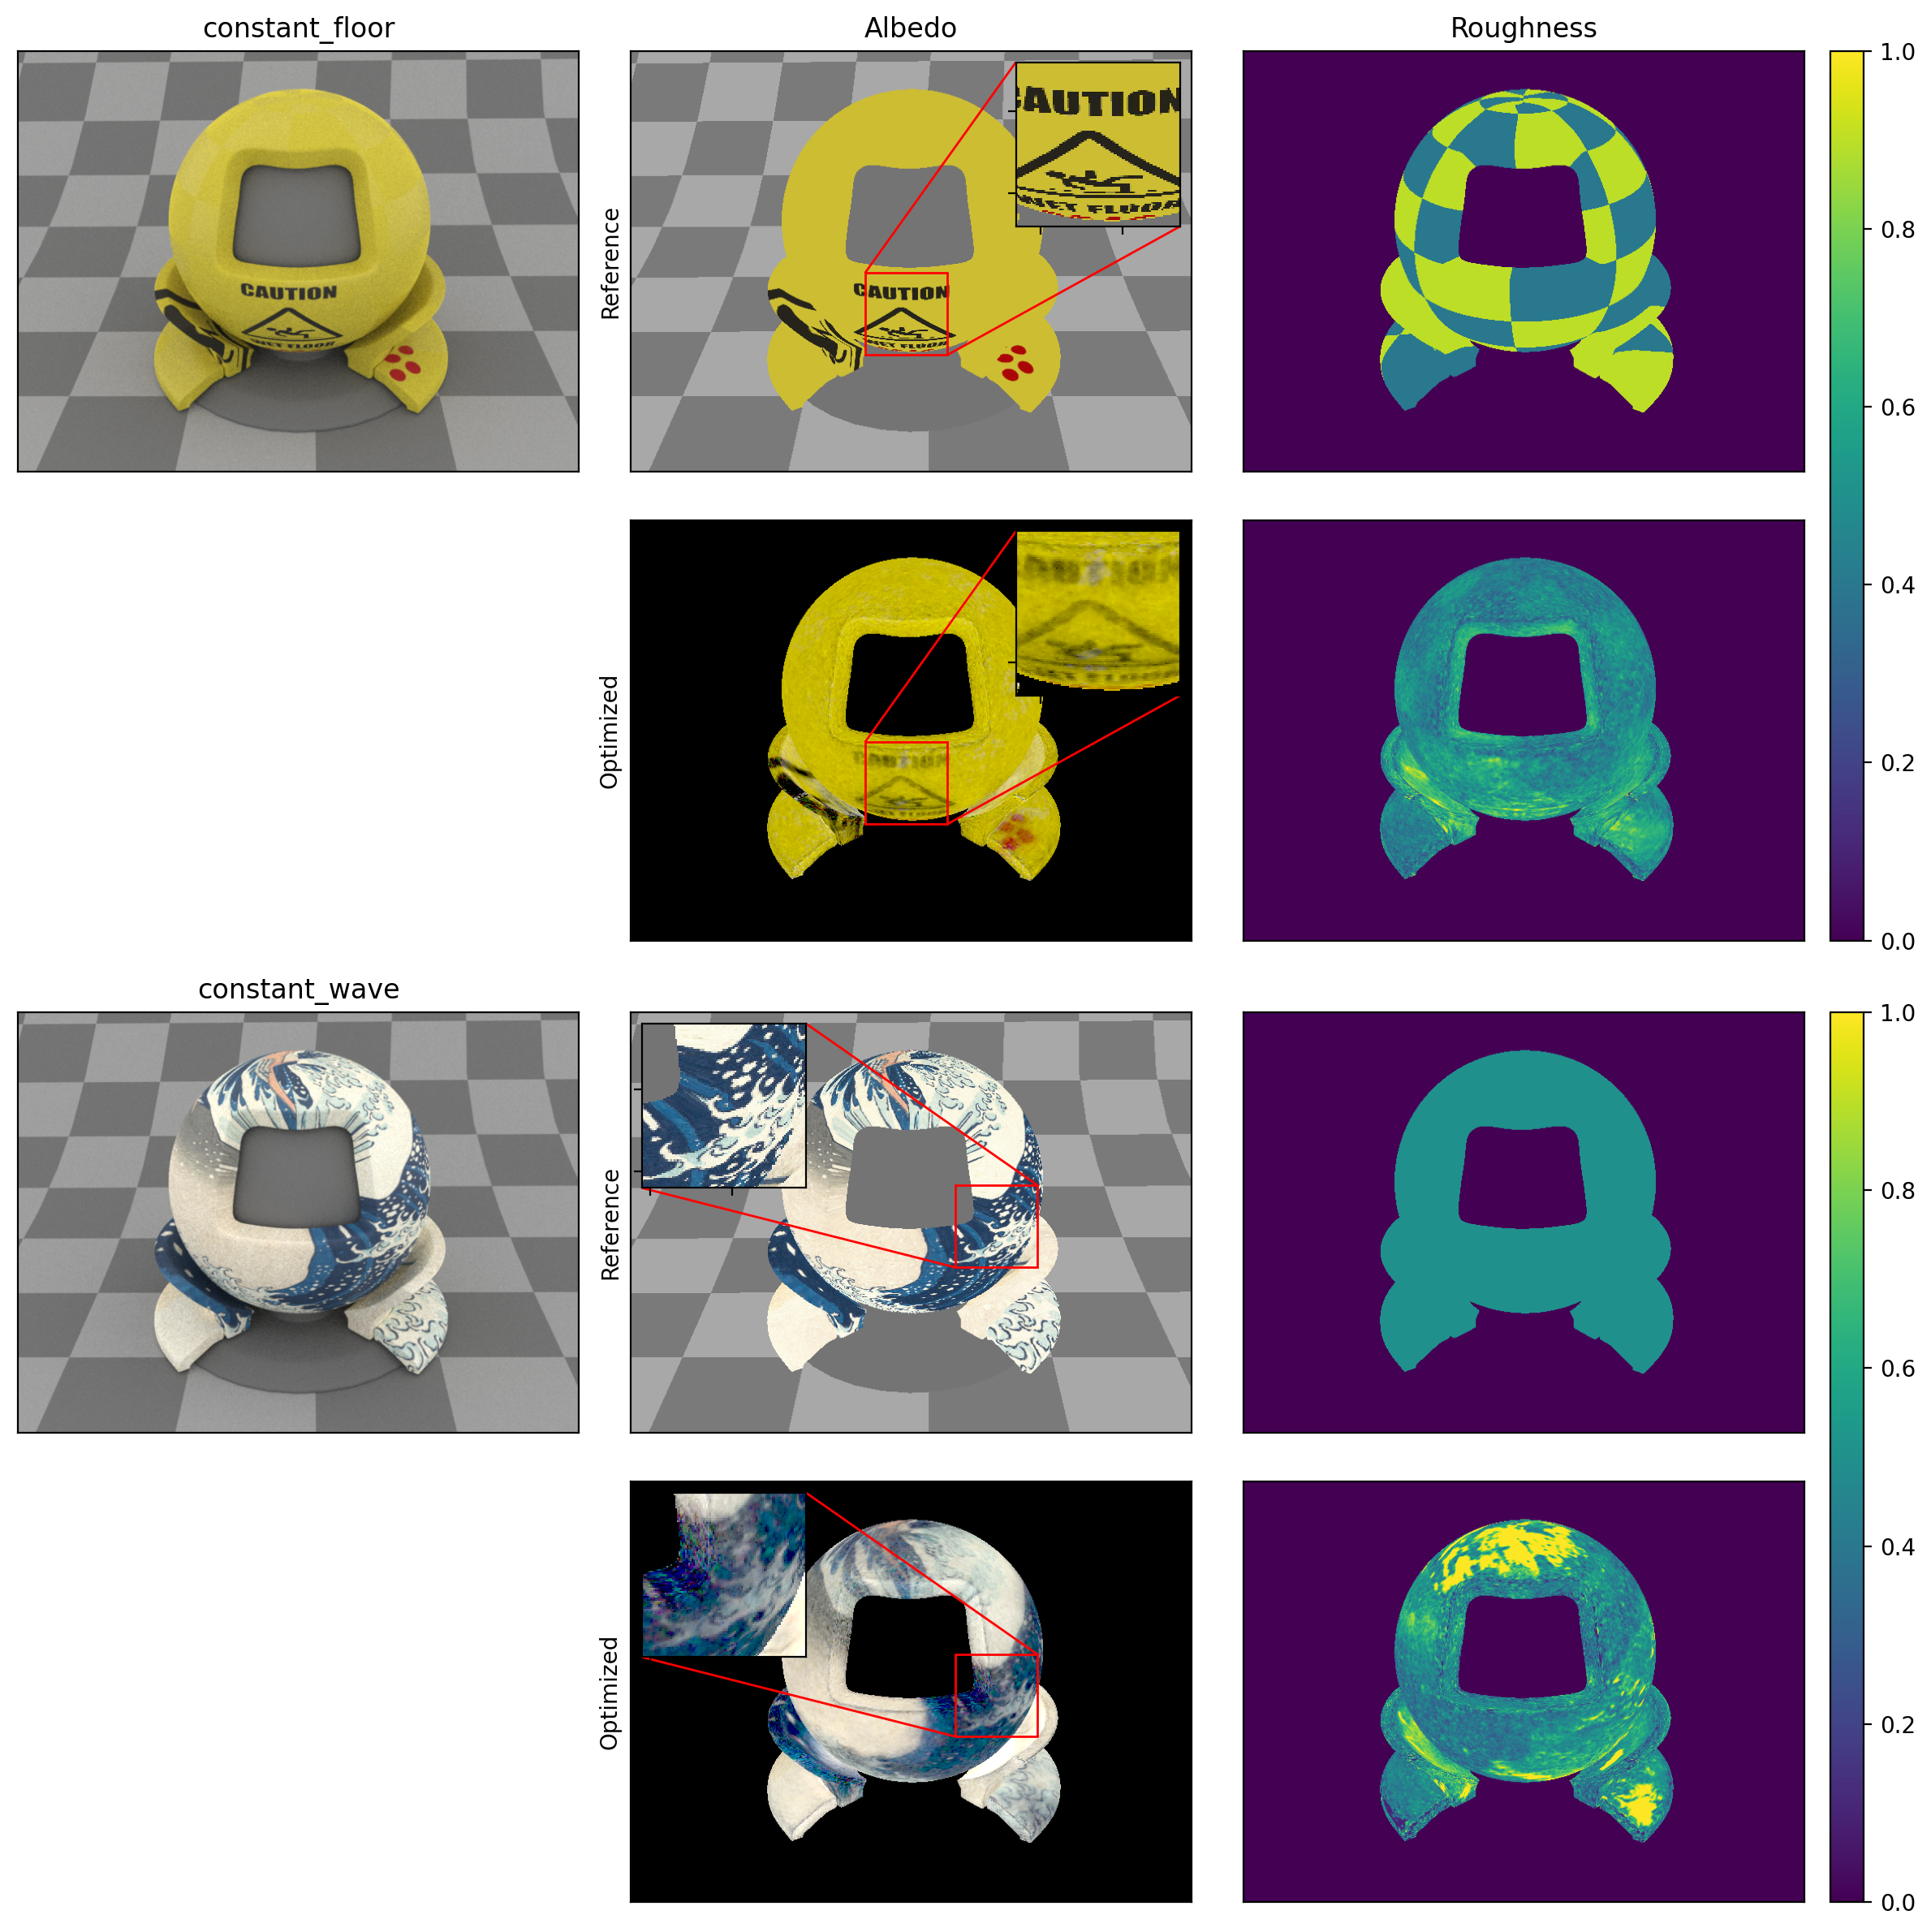

In [2]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from mpl_toolkits.axes_grid1.inset_locator import _TransformedBboxWithCallback, BboxPatch, BboxConnector

def mark_inset_(parent_axes, inset_axes, loc1, loc2, loc3, loc4, **kwargs):
    rect = _TransformedBboxWithCallback(
        inset_axes.viewLim, parent_axes.transData,
        callback=parent_axes._unstale_viewLim)

    kwargs.setdefault("fill", bool({'fc', 'facecolor', 'color'}.intersection(kwargs)))
    pp = BboxPatch(rect, **kwargs)
    parent_axes.add_patch(pp)

    p1 = BboxConnector(inset_axes.bbox, rect, loc1=loc1, loc2=loc2, **kwargs)
    inset_axes.add_patch(p1)
    p1.set_clip_on(False)
    p2 = BboxConnector(inset_axes.bbox, rect, loc1=loc3, loc2=loc4, **kwargs)
    inset_axes.add_patch(p2)
    p2.set_clip_on(False)

    return pp, p1, p2


fp = "/home/jonathan/Documents/volprim-balance/exp22/"
scenes = ["floor", "wave"]

num_scenes = len(scenes)
ylabels = ["Optimized", "Reference"]

# Set up figure and image grid
scale = 6
fig = plt.figure(figsize=(num_scenes * scale, 2.0 * scale), dpi=200)

for bigrow in [0,1]:

    grid = ImageGrid(fig, (2,1,bigrow + 1),
                    nrows_ncols=(2,3),
                    axes_pad=0.3,
                    aspect=False,
                    share_all=True,
                    cbar_location="right",
                    cbar_mode="single",
                    cbar_size="3%",
                    cbar_pad=0.15,
                    )


    scene = scenes[bigrow]
    plt.title(f"constant_{scene}")
    img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

    ax = grid[0]
    ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"constant_{scene}")
    # ax.set_ylabel("Reference")
    
    ax = grid[3]
    ax.set_axis_off()

    # plt.setp(ax.get_xticklabels(), visible=False)
    # plt.setp(ax.get_yticklabels(), visible=False)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    # ax.tick_params(axis='both', which='both', length=0)
    # ax.set_ylabel("Optimized")

    for row in [0,1]:
        # ax.set_ylabel("Reference" if row == 0 else "Optimized")
        # ax.set_ylabel("Reference")
        filename = f"{scene}_opt.exr" if row == 1 else f"{scene}_ref.exr"
        buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
        img_albedo  = mi.TensorXf(buffer['base_color'])
        attrs       = mi.TensorXf(buffer['<root>'])
        img_metal   = attrs[:,:,1]
        img_rough   = attrs[:,:,2]
        # anisotropic = attrs[:,:,0]
        # spec_tint   = attrs[:,:,3]

        col = 1
        ax = grid[3 * row + col]
        ax.imshow(img_albedo ** (1/2.2))
        ax.set_ylabel(ylabels[row])
        if bigrow == 0 and row == 0:
            ax.set_title("Albedo")
        ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)


        col = 2
        ax = grid[3 * row + col]
        im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
        if bigrow == 0 and row == 0:
            ax.set_title("Roughness")

        # draw insets
        # if row == 1:
        extent = (0, 683, 0, 512)

        if bigrow == 0:
            # sub region of the original image
            x1, x2, y1, y2 = 285, 385, 370, 270
        else:
            x1, x2, y1, y2 = 395, 495, 310, 210

        col = 1; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=1 if bigrow == 0 else 2) # zoom = 6
        axins.imshow(img_albedo ** (1/2.2), extent=(0,683,0,512), interpolation="nearest",
                    origin="lower")
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        if bigrow == 0:
            mark_inset_(ax, axins, loc1=2, loc2=3, loc3=4, loc4=1, fc="none", ec="r")
        else:
            mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="r")


    ax.cax.colorbar(im)
    
plt.tight_layout()
plt.savefig("Exp2-2_albedo.png")

/tmp/ipykernel_3598525/943479854.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


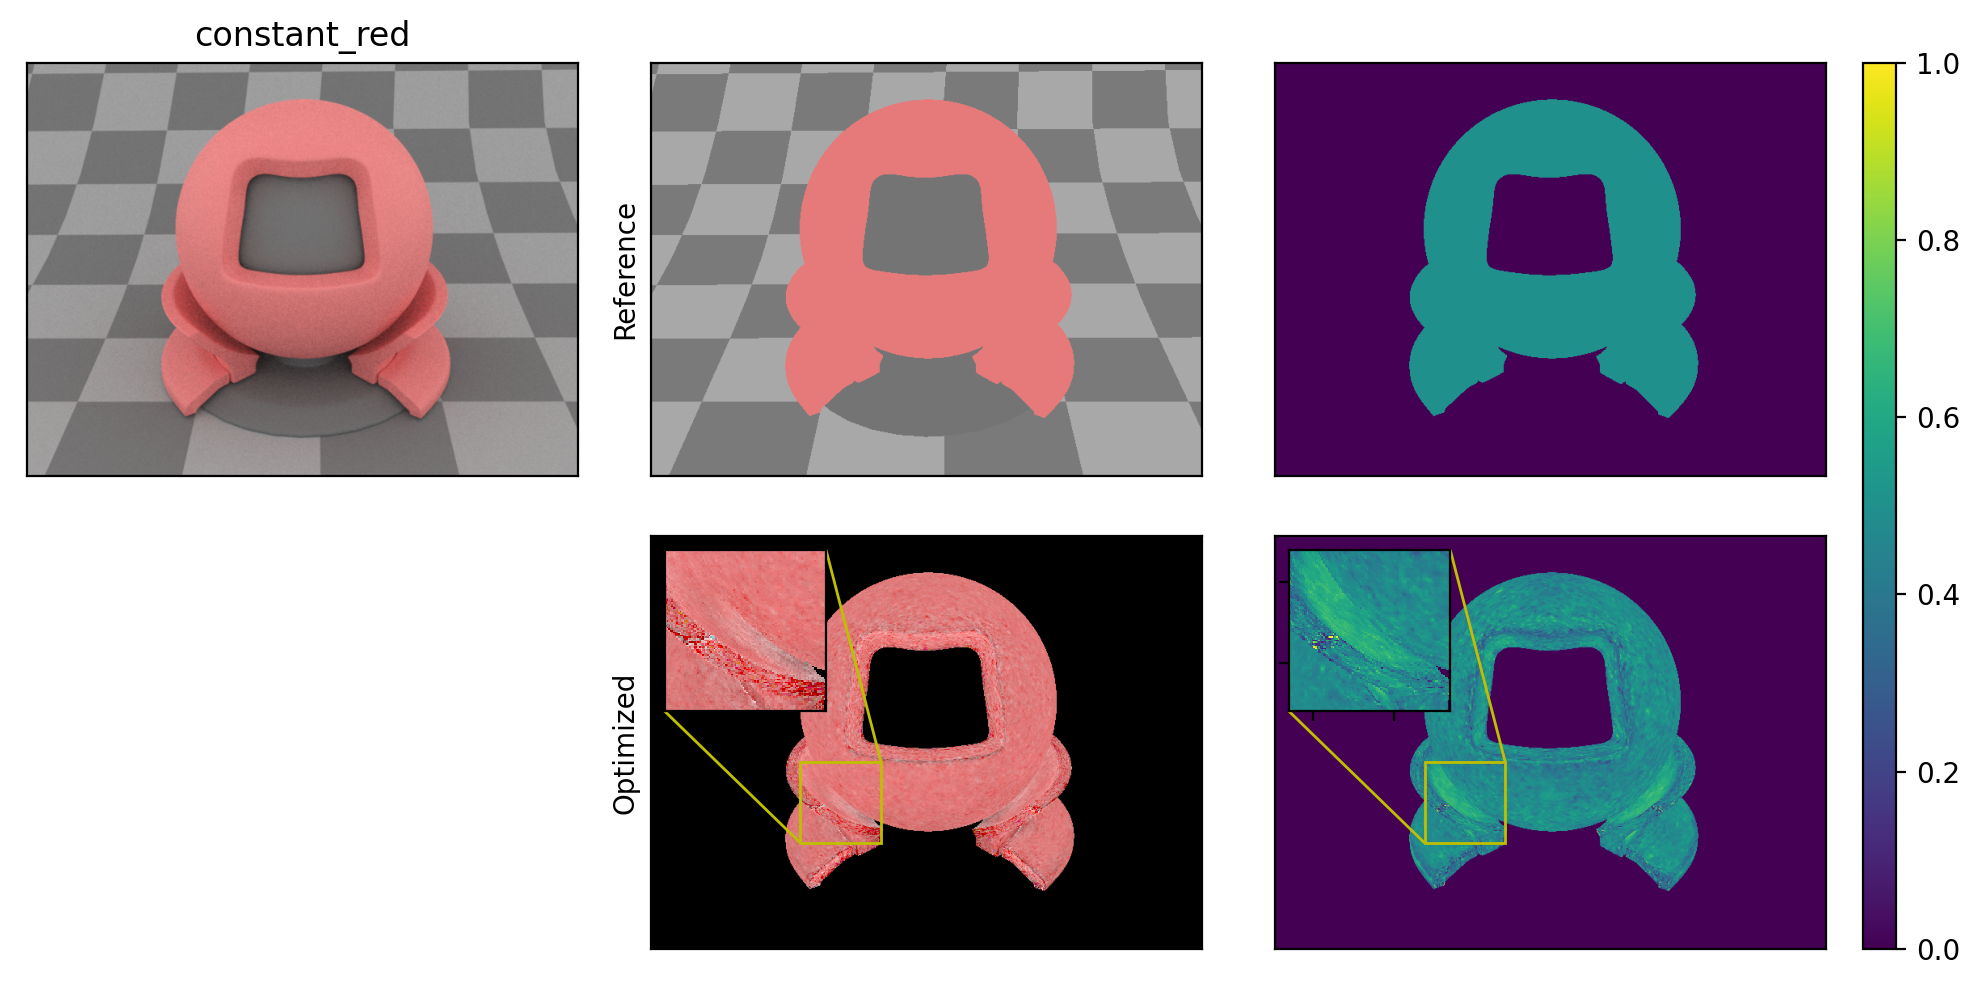

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

scenes = ["red"]

num_scenes = len(scenes)
ylabels = ["Optimized", "Reference"]

# Set up figure and image grid
scale = 6
fig = plt.figure(figsize=(10, 5), dpi=200)

grid = ImageGrid(fig, (1,1,1),
                nrows_ncols=(2,3),
                axes_pad=0.3,
                aspect=False,
                share_all=True,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="3%",
                cbar_pad=0.15,
                )


plt.title(f"constant_{scene}")
scene = scenes[0]
img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

ax = grid[0]
ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"constant_{scene}")

ax = grid[3]
ax.set_axis_off()

for row in [0,1]:
    filename = f"{scene}_opt.exr" if row == 1 else f"{scene}_ref.exr"
    buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
    img_albedo  = mi.TensorXf(buffer['base_color'])
    attrs       = mi.TensorXf(buffer['<root>'])
    # img_metal   = attrs[:,:,1]
    img_rough   = attrs[:,:,2]

    col = 1
    ax = grid[3 * row + col]
    ax.imshow(img_albedo ** (1/2.2))
    ax.set_ylabel(ylabels[row])
    if bigrow == 0 and row == 0:
        ax.set_title("Albedo")
    ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)

    col = 2
    ax = grid[3 * row + col]
    im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
    if bigrow == 0 and row == 0:
        ax.set_title("Roughness")

    # draw insets
    if row == 1:
        extent = (0, 683, 0, 512)
        # sub region of the original image
        x1, x2, y1, y2 = 185, 285, 380, 280

        col = 1; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
        axins.imshow(img_albedo ** (1/2.2), extent=(0,683,0,512), interpolation="nearest",
                    origin="lower")
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")
        # # inset Axes....
        # axins = ax.inset_axes(
        #     [-0.03, 0.57, 0.4, 0.4],
        #     xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
        # axins.imshow(img_albedo ** (1/2.2), extent=extent, origin="lower")
        # ax.indicate_inset_zoom(axins, edgecolor="y", linewidth=1)

        col = 2; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
        axins.imshow(img_rough, extent=(0,683,0,512), interpolation="nearest",
                    origin="lower")
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

ax.cax.colorbar(im)
    
plt.draw()

plt.tight_layout()
plt.savefig("Exp2-1_albedo.png")

/tmp/ipykernel_3598525/2531802277.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


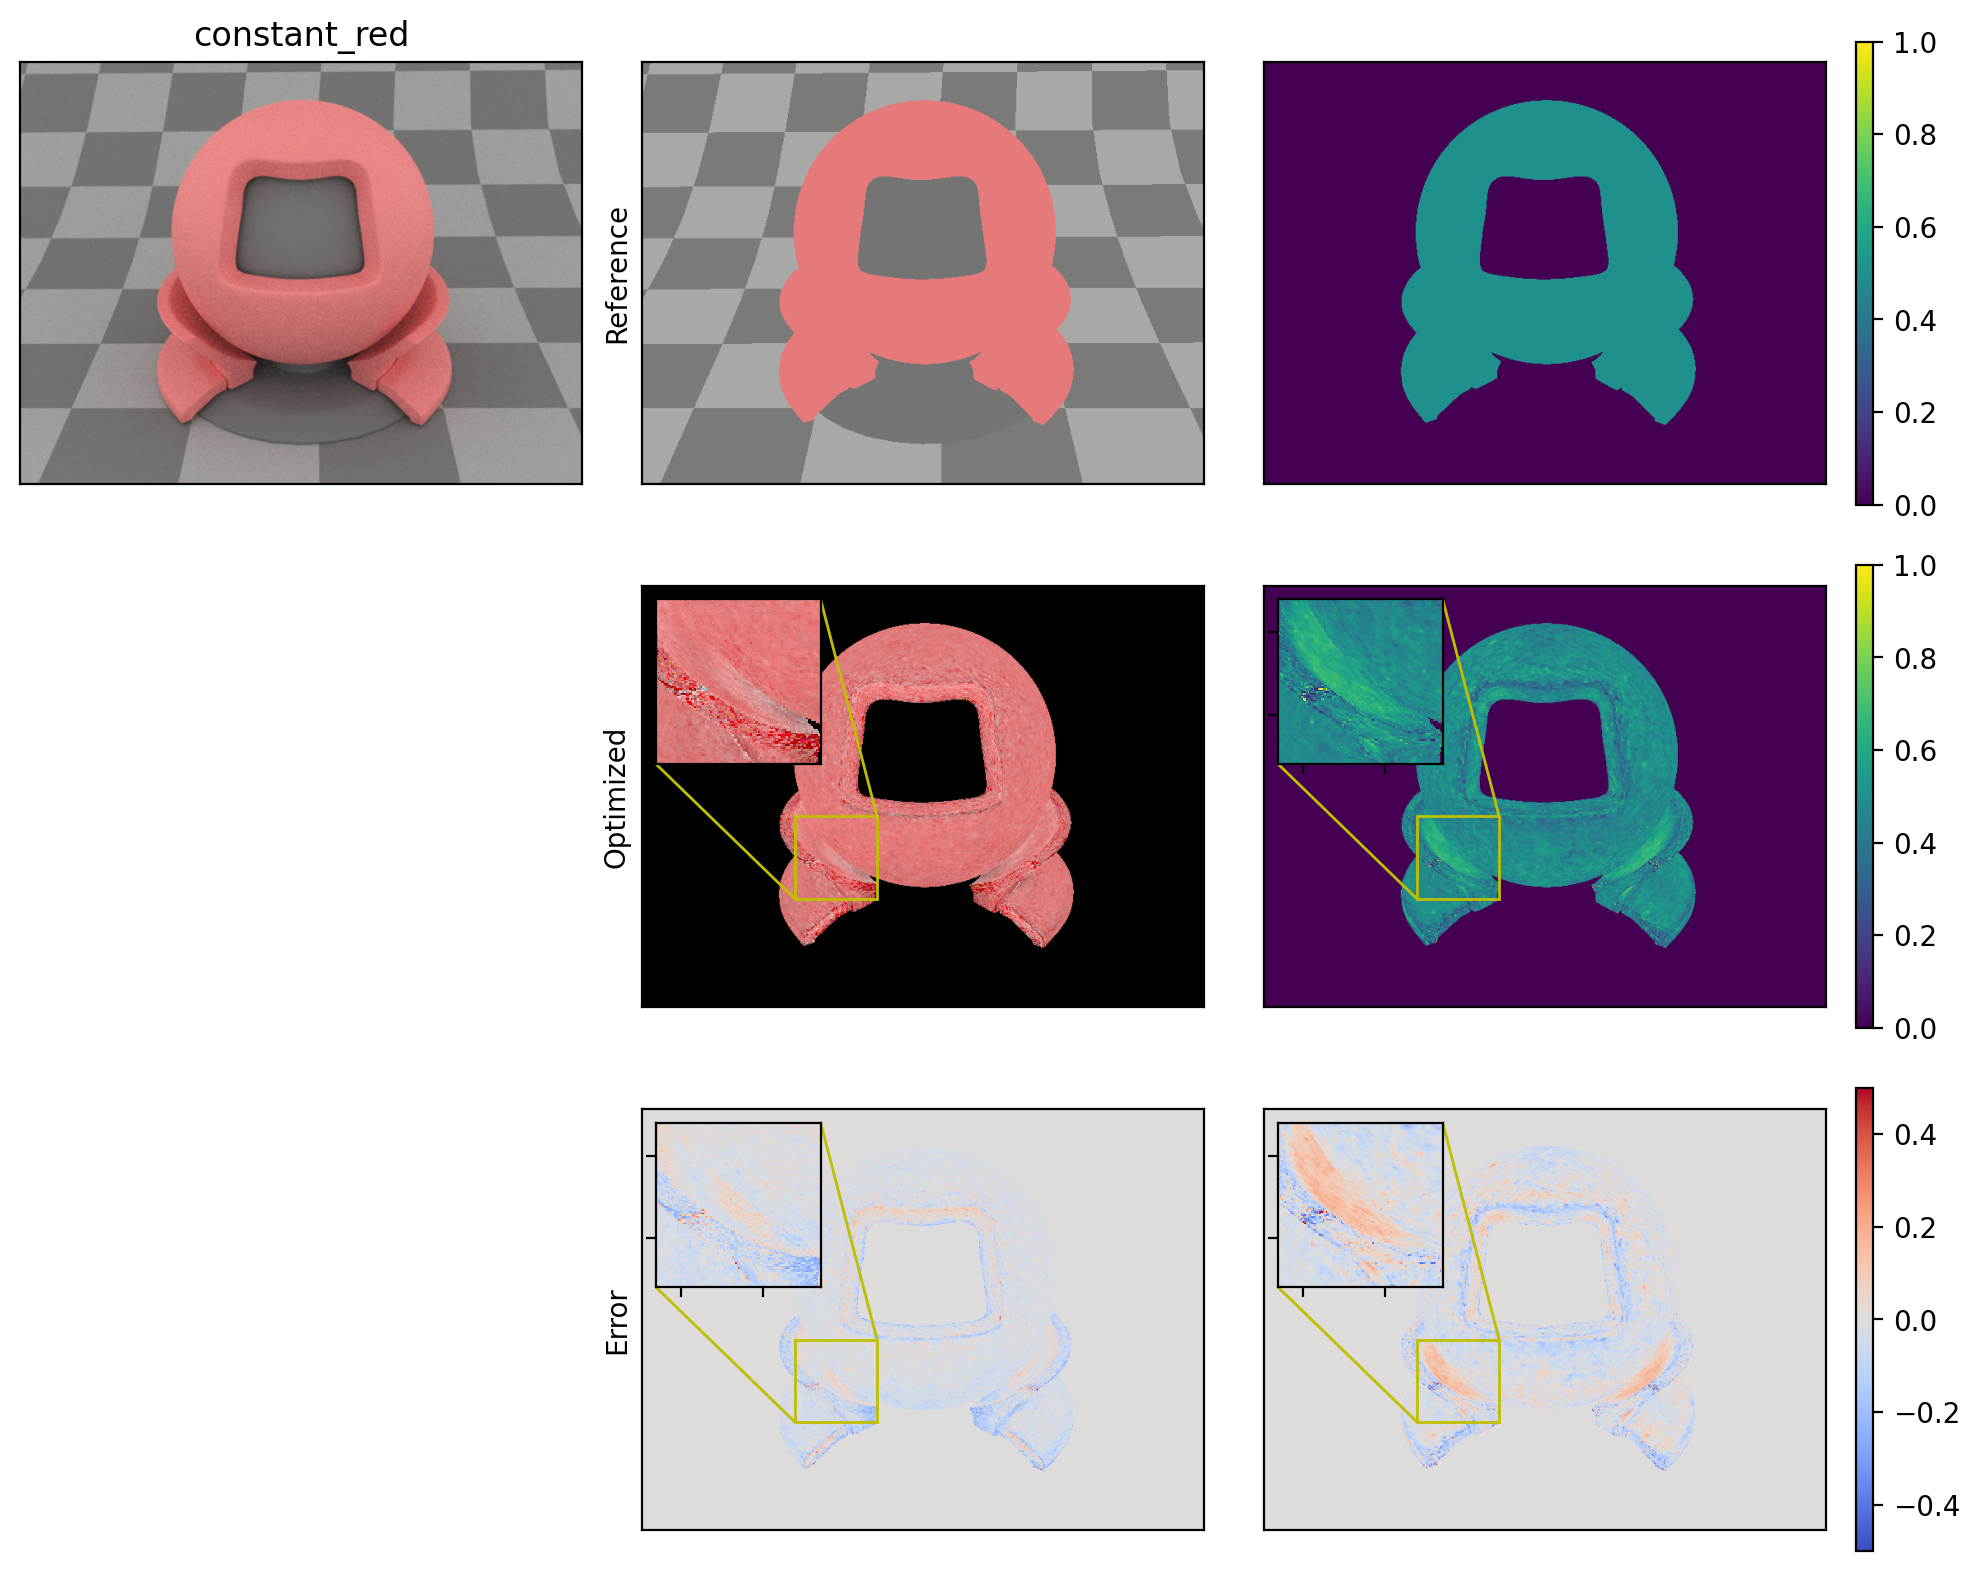

In [4]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def plot_scene(scene, fp = "/home/jonathan/Documents/volprim-balance/exp22/", error_range = 0.1, inset_loc = None):
    ylabels = ["Optimized", "Reference"]

    # Set up figure and image grid
    fig = plt.figure(figsize=(10, 8), dpi=200)

    grid = ImageGrid(fig, (1,1,1),
                    nrows_ncols=(3,3),
                    axes_pad=0.3,
                    aspect=False,
                    share_all=True,
                    cbar_location="right",
                    cbar_mode="edge",
                    cbar_size="3%",
                    cbar_pad=0.15,
                    )


    plt.title(f"constant_{scene}")
    img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

    ax = grid[0]
    ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"constant_{scene}")

    ax = grid[3]
    ax.set_axis_off()

    def load(filename):
        buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
        img_albedo  = mi.TensorXf(buffer['base_color'])
        attrs       = mi.TensorXf(buffer['<root>'])
        # img_metal   = attrs[:,:,1]
        img_rough   = attrs[:,:,2]
        return img_albedo, img_rough
    
    img_albedo_ref, img_rough_ref = load(f"{scene}_ref.exr")
    img_albedo_opt, img_rough_opt = load(f"{scene}_opt.exr")


    for row in [0,1]:
        img_albedo  = img_albedo_ref if row == 0 else img_albedo_opt
        img_rough   = img_rough_ref  if row == 0 else img_rough_opt

        col = 1
        ax = grid[3 * row + col]
        ax.imshow(img_albedo ** (1/2.2))
        ax.set_ylabel(ylabels[row])
        if bigrow == 0 and row == 0:
            ax.set_title("Albedo")
        ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)

        col = 2
        ax = grid[3 * row + col]
        im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
        if bigrow == 0 and row == 0:
            ax.set_title("Roughness")
        ax.cax.colorbar(im)

        # draw insets
        if inset_loc is not None and row == 1:
            # sub region of the original image
            x1, x2, y1, y2 = inset_loc

            col = 1; ax = grid[3 * row + col]
            axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
            axins.imshow(img_albedo ** (1/2.2), extent=(0,683,0,512), interpolation="nearest",
                        origin="lower")
            axins.set_xlim(x1, x2)
            axins.set_ylim(y1, y2)
            plt.xticks(visible=False)
            plt.yticks(visible=False)
            mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

            col = 2; ax = grid[3 * row + col]
            axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
            axins.imshow(img_rough, extent=(0,683,0,512), interpolation="nearest",
                        origin="lower")
            axins.set_xlim(x1, x2)
            axins.set_ylim(y1, y2)
            plt.xticks(visible=False)
            plt.yticks(visible=False)
            mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")


    row = 2
    grid[row * 3].remove()

    albedo_mask = dr.select(load("/home/jonathan/Documents/volprim-balance/exp22/red_ref.exr")[0][:,:,0] > 0.5, 1.0, 0.0)

    img_rough  = img_rough_opt  - img_rough_ref
    img_albedo = img_albedo_opt - img_albedo_ref
    img_albedo = (img_albedo[:,:,0] + img_albedo[:,:,1] + img_albedo[:,:,2]) / 3
    img_albedo = img_albedo * albedo_mask
    col = 1
    ax = grid[3 * row + col]
    im = ax.imshow(img_albedo, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if bigrow == 0 and row == 0:
        ax.set_title("Albedo")
    ax.set_ylabel("Error", visible=True)
    ax.cax.colorbar(im)

    col = 2
    ax = grid[3 * row + col]
    im = ax.imshow(img_rough, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if bigrow == 0 and row == 0:
        ax.set_title("Roughness")
    ax.cax.colorbar(im)

    # draw insets
    if inset_loc is not None:
        # sub region of the original image
        x1, x2, y1, y2 = inset_loc

        col = 1; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
        axins.imshow(img_albedo, extent=(0,683,0,512), interpolation="nearest",
                    origin="lower", vmin=-error_range, vmax=error_range, cmap='coolwarm')
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

        col = 2; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
        axins.imshow(img_rough, extent=(0,683,0,512), interpolation="nearest",
                    origin="lower", vmin=-error_range, vmax=error_range, cmap='coolwarm')
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

    # ax.cax.colorbar(im)
        
    plt.draw()
    plt.tight_layout()


plot_scene("red", error_range=0.5, inset_loc = (185, 285, 380, 280))

plt.savefig("Exp2-1_albedo.png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04429989..1.5522443].
/tmp/ipykernel_3598525/1450056212.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


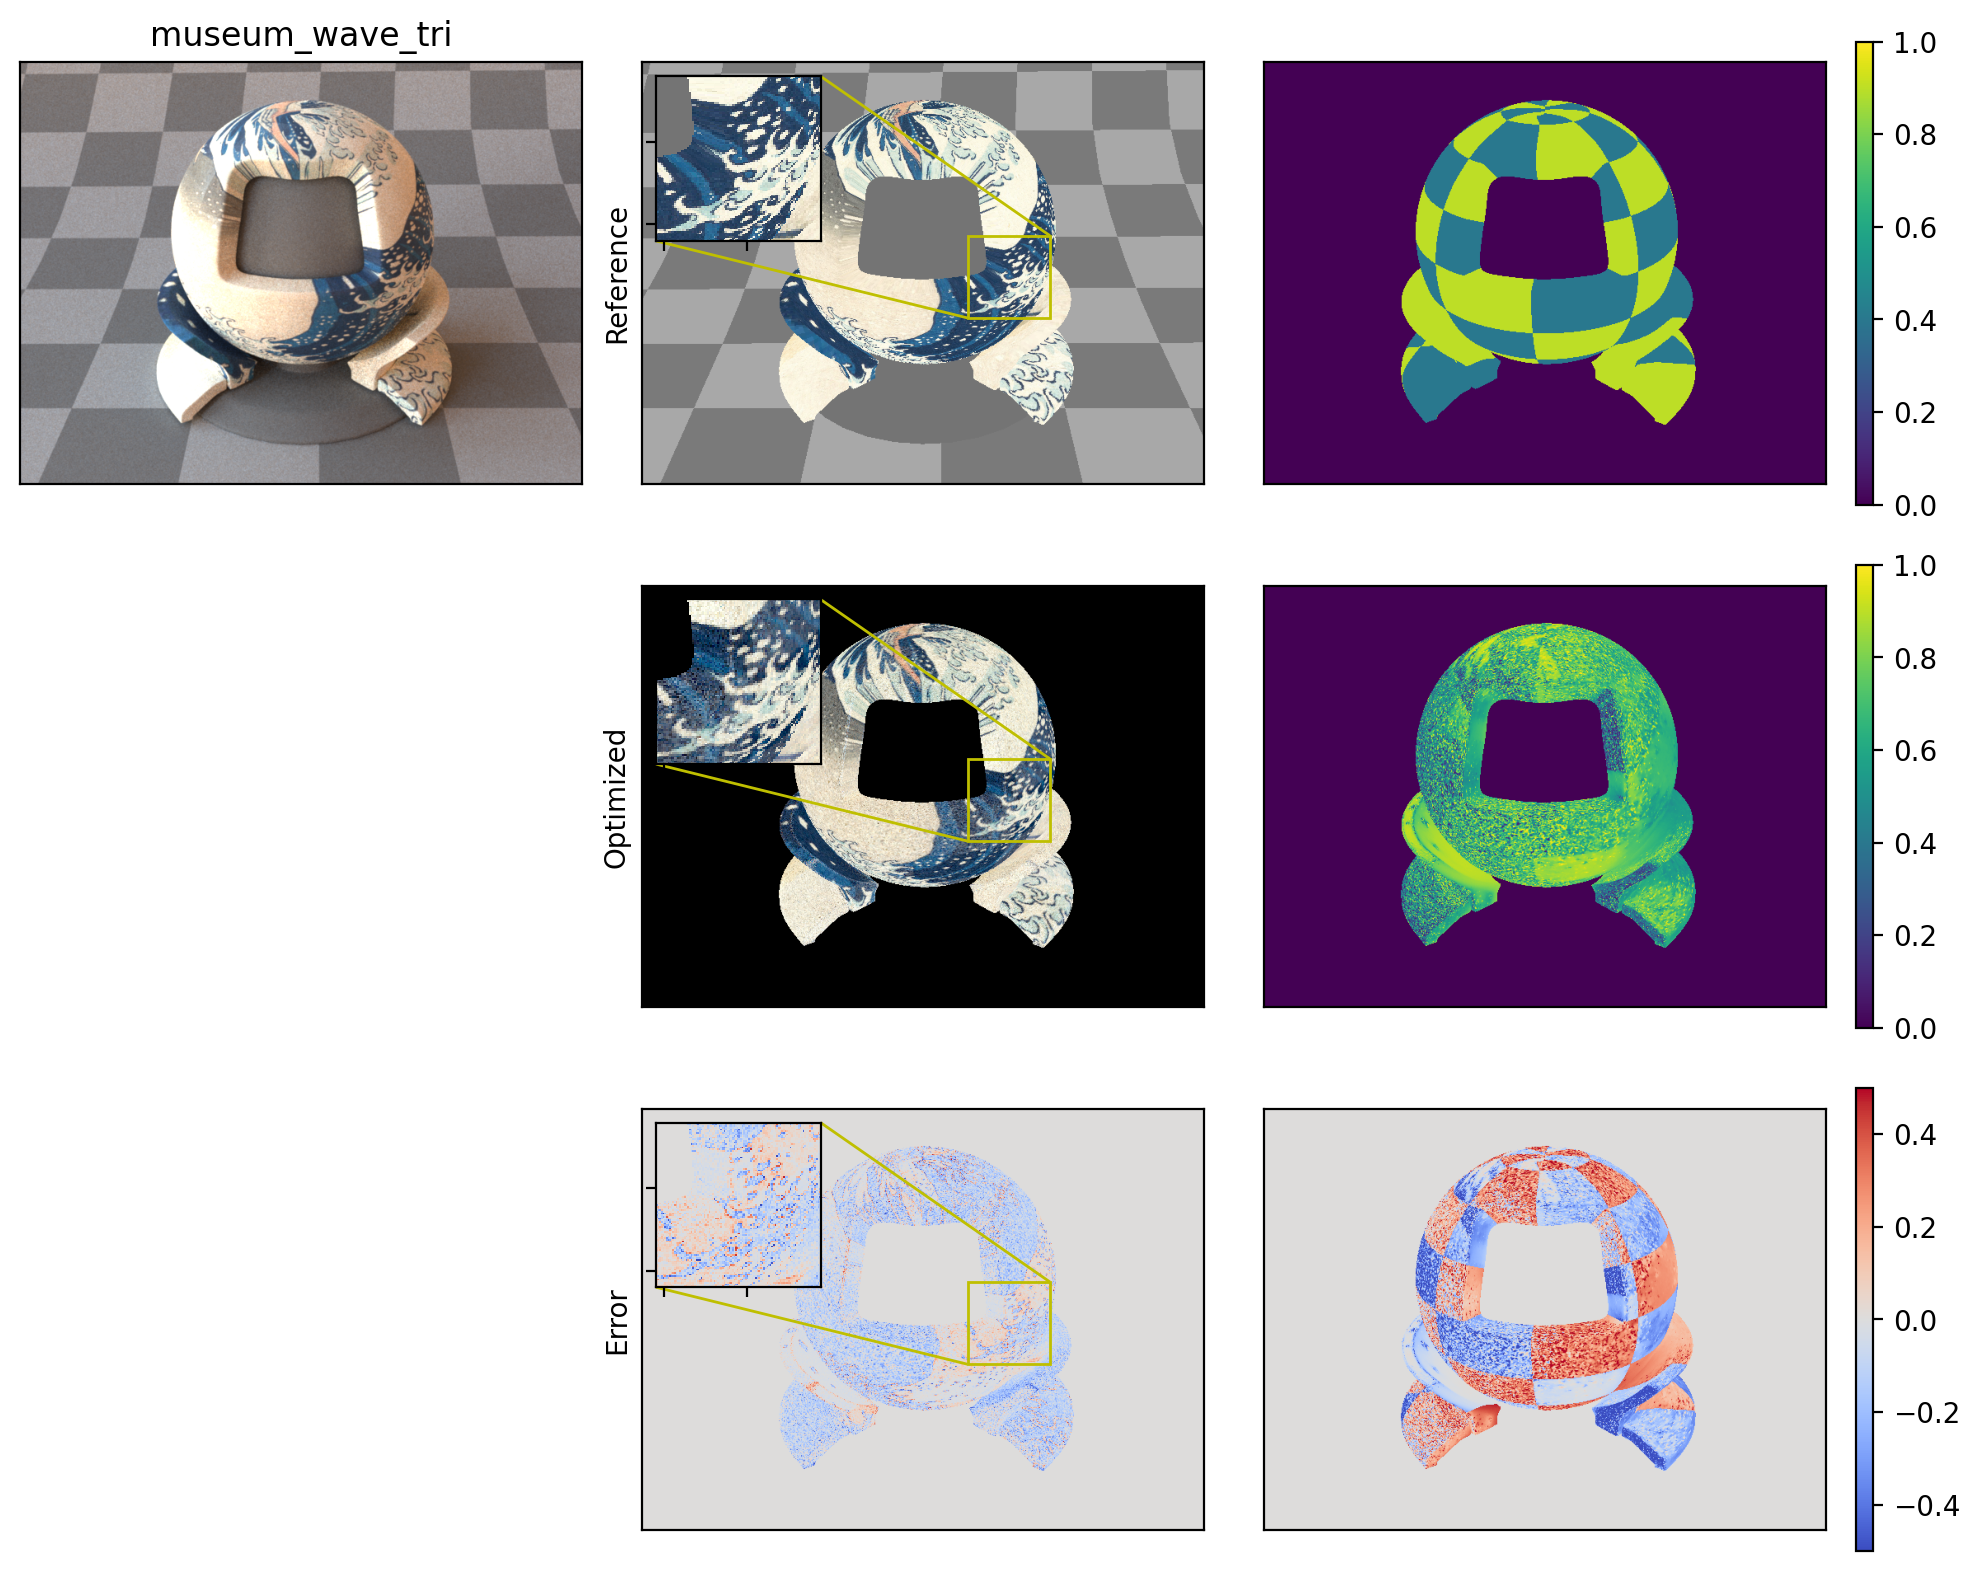

In [9]:
fp = "/home/jonathan/Documents/volprim-balance/exp31/"
scene = "wave_tri"

def plot_scene(scene, fp = "/home/jonathan/Documents/volprim-balance/exp22/", error_range = 0.1, inset_loc = None):
    ylabels = ["Optimized", "Reference"]

    # Set up figure and image grid
    fig = plt.figure(figsize=(10, 8), dpi=200)

    grid = ImageGrid(fig, (1,1,1),
                    nrows_ncols=(3,3),
                    axes_pad=0.3,
                    aspect=False,
                    share_all=True,
                    cbar_location="right",
                    cbar_mode="edge",
                    cbar_size="3%",
                    cbar_pad=0.15,
                    )


    plt.title(f"museum_{scene}")
    img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

    ax = grid[0]
    ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"museum_{scene}")

    ax = grid[3]
    ax.set_axis_off()

    def load(filename):
        buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
        img_albedo  = mi.TensorXf(buffer['base_color'])
        attrs       = mi.TensorXf(buffer['<root>'])
        # img_metal   = attrs[:,:,1]
        img_rough   = attrs[:,:,2]
        return img_albedo, img_rough
    
    img_albedo_ref, img_rough_ref = load(f"{scene}_ref.exr")
    img_albedo_opt, img_rough_opt = load(f"{scene}_opt.exr")


    for row in [0,1]:
        img_albedo  = img_albedo_ref if row == 0 else img_albedo_opt
        img_rough   = img_rough_ref  if row == 0 else img_rough_opt

        col = 1
        ax = grid[3 * row + col]
        ax.imshow(img_albedo ** (1/2.2))
        ax.set_ylabel(ylabels[row])
        if bigrow == 0 and row == 0:
            ax.set_title("Albedo")
        ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)

        col = 2
        ax = grid[3 * row + col]
        im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
        if bigrow == 0 and row == 0:
            ax.set_title("Roughness")
        ax.cax.colorbar(im)

        # draw insets
        if inset_loc is not None and row <= 1:
            # sub region of the original image
            x1, x2, y1, y2 = inset_loc

            col = 1; ax = grid[3 * row + col]
            axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
            axins.imshow(img_albedo ** (1/2.2), extent=(0,683,0,512), interpolation="nearest",
                        origin="lower")
            axins.set_xlim(x1, x2)
            axins.set_ylim(y1, y2)
            plt.xticks(visible=False)
            plt.yticks(visible=False)
            mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

    row = 2
    grid[row * 3].remove()

    albedo_mask = dr.select(load("/home/jonathan/Documents/volprim-balance/exp22/red_ref.exr")[0][:,:,0] > 0.5, 1.0, 0.0)

    img_rough  = img_rough_opt  - img_rough_ref
    img_albedo = img_albedo_opt - img_albedo_ref
    img_albedo = (img_albedo[:,:,0] + img_albedo[:,:,1] + img_albedo[:,:,2]) / 3
    img_albedo = img_albedo * albedo_mask
    col = 1
    ax = grid[3 * row + col]
    im = ax.imshow(img_albedo, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if bigrow == 0 and row == 0:
        ax.set_title("Albedo")
    ax.set_ylabel("Error", visible=True)
    ax.cax.colorbar(im)

    col = 2
    ax = grid[3 * row + col]
    im = ax.imshow(img_rough, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if bigrow == 0 and row == 0:
        ax.set_title("Roughness")

    # draw insets
    if inset_loc is not None:
        # sub region of the original image
        x1, x2, y1, y2 = inset_loc

        col = 1; ax = grid[3 * row + col]
        axins = zoomed_inset_axes(ax, 2., loc=2) # zoom = 6
        axins.imshow(img_albedo, extent=(0,683,0,512), interpolation="nearest",
                    origin="lower", vmin=-error_range, vmax=error_range, cmap='coolwarm')
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        plt.xticks(visible=False)
        plt.yticks(visible=False)
        mark_inset_(ax, axins, loc1=1, loc2=4, loc3=3, loc4=2, fc="none", ec="y")

    ax.cax.colorbar(im)        
    plt.draw()
    plt.tight_layout()


plot_scene(scene, fp, 0.5, (395, 495, 310, 210))
plt.savefig("Exp3-1_albedo.png")

In [6]:
# fp = "/home/jonathan/Documents/volprim-balance/exp22/"
# scenes = ["floor", "wave"]

# num_scenes = len(scenes)
# ylabels = ["Optimized", "Reference"]

# # Set up figure and image grid
# scale = 4
# fig = plt.figure(figsize=(num_scenes * scale, 2.2 * scale), dpi=200)

# plt.subplot(221)
# scene = scenes[0]
# plt.title(f"constant_{scene}")
# img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))
# plt.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
# ax = plt.gca()
# plt.setp(ax.get_xticklabels(), visible=False)
# plt.setp(ax.get_yticklabels(), visible=False)
# ax.tick_params(axis='both', which='both', length=0)

# plt.subplot(223)
# scene = scenes[1]
# plt.title(f"constant_{scene}")
# img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))
# plt.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
# ax = plt.gca()
# plt.setp(ax.get_xticklabels(), visible=False)
# plt.setp(ax.get_yticklabels(), visible=False)
# ax.tick_params(axis='both', which='both', length=0)



# for bigrow in [0,1]:

#     grid = ImageGrid(fig, (2,2, 2 * bigrow + 2),
#                     nrows_ncols=(2,2),
#                     axes_pad=0.3,
#                     share_all=True,
#                     cbar_location="right",
#                     cbar_mode="single",
#                     cbar_size="3%",
#                     cbar_pad=0.15,
#                     )

#     for row in [0,1]:
#         # ax.set_ylabel("Reference" if row == 0 else "Optimized")
#         # ax.set_ylabel("Reference")
#         filename = f"{scene}_opt.exr" if row == 1 else f"{scene}_ref.exr"
#         buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
#         img_albedo  = mi.TensorXf(buffer['base_color'])
#         attrs       = mi.TensorXf(buffer['<root>'])
#         img_metal   = attrs[:,:,1]
#         img_rough   = attrs[:,:,2]
#         # anisotropic = attrs[:,:,0]
#         # spec_tint   = attrs[:,:,3]

#         col = 0
#         ax = grid[2 * row + col]
#         ax.imshow(img_albedo ** (1/2.2))
#         ax.set_ylabel(ylabels[row])
#         if bigrow == 0 and row == 0:
#             ax.set_title("Albedo")
#         ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)


#         col = 1
#         ax = grid[2 * row + col]
#         im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
#         if bigrow == 0 and row == 0:
#             ax.set_title("Roughness")

#     ax.cax.colorbar(im)

# # plt.tight_layout()
# # plt.savefig("Exp2-2_albedo.png")